# Group 8 - ANN Lab 3 (Pre-trained CNNs)

This notebook answers all required items in one file:
1. Hyperparameter tuning of `ImageDataGenerator`. Assigned: Abelardo, Aasen Sofia P.
2. VGG19 implementation and comparison with VGG16. Assigned: Gumban, Joevanni Paulo T.
3. VGG16 test accuracy vs training sample sizes `[500, 1000, 2000, 5000, 10000, 15000]` (no augmentation, 30 epochs/run). Assigned: Aquino, Matthew Benedict U.
4. Xception (Extreme Inception) implementation and comparison with VGG models. Assigned: Balingit, Den Mar F.

Each training item saves model artifacts as `.h5`.

In [1]:
import os
import random
import shutil
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras import layers, models, optimizers
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.preprocessing import image as keras_image
from tensorflow.keras.applications import VGG16, VGG19, Xception

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

PROJECT_DIR = Path.cwd()
DATA_DIR = PROJECT_DIR / 'data'
OUTPUT_DIR = PROJECT_DIR / 'models'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

BASE_DATASET_DIR = DATA_DIR / 'cats_and_dogs_from_petimages'
WORKING_SPLIT_DIR = DATA_DIR / 'working_split_for_lab3'

print('TensorFlow version:', tf.__version__)
print('Project directory:', PROJECT_DIR)
print('Base dataset:', BASE_DATASET_DIR)
print('Output directory:', OUTPUT_DIR)

I0000 00:00:1777516112.183840   21758 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1777516113.088504   21758 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1777516115.585330   21758 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


TensorFlow version: 2.21.0
Project directory: /home/solyvie/workspace/cs-projects/25263CSDMachineLearning/[7] Group 8 - Module 6 CNN Part 3 - Using Pre-Trained Networks
Base dataset: /home/solyvie/workspace/cs-projects/25263CSDMachineLearning/[7] Group 8 - Module 6 CNN Part 3 - Using Pre-Trained Networks/data/cats_and_dogs_from_petimages
Output directory: /home/solyvie/workspace/cs-projects/25263CSDMachineLearning/[7] Group 8 - Module 6 CNN Part 3 - Using Pre-Trained Networks/models


In [2]:
def count_split(split_dir: Path):
    counts = {}
    total = 0
    for cls in ['cats', 'dogs']:
        cls_dir = split_dir / cls
        n = len(list(cls_dir.glob('*'))) if cls_dir.exists() else 0
        counts[cls] = n
        total += n
    counts['total'] = total
    return counts


def print_split_table(title, split_map):
    rows = []
    for split_name, split_dir in split_map.items():
        c = count_split(split_dir)
        rows.append({
            'split': split_name,
            'cats': c['cats'],
            'dogs': c['dogs'],
            'total': c['total'],
            'path': str(split_dir)
        })
    df = pd.DataFrame(rows)
    print(f'\n{title}')
    display(df)
    return df


# Prepare train/validation/test directories.
# If no dedicated test folder exists, create a disjoint val/test split from the provided validation folder.
source_train = BASE_DATASET_DIR / 'train'
source_val = BASE_DATASET_DIR / 'validation'
source_test = BASE_DATASET_DIR / 'test'

if source_test.exists():
    train_dir = source_train
    validation_dir = source_val
    test_dir = source_test
    split_note = 'Using dataset-provided train/validation/test directories.'
else:
    if WORKING_SPLIT_DIR.exists():
        shutil.rmtree(WORKING_SPLIT_DIR)

    for split in ['train', 'validation', 'test']:
        for cls in ['cats', 'dogs']:
            (WORKING_SPLIT_DIR / split / cls).mkdir(parents=True, exist_ok=True)

    # Keep original train set intact (2000 total: 1000 cats + 1000 dogs).
    for cls in ['cats', 'dogs']:
        src_cls = source_train / cls
        dst_cls = WORKING_SPLIT_DIR / 'train' / cls
        for f in src_cls.iterdir():
            if f.is_file():
                shutil.copy2(f, dst_cls / f.name)

    # Split original validation set into validation/test (50/50) to create a true holdout test set.
    # This avoids test leakage, but reduces val/test to 500 each (250/class).
    for cls in ['cats', 'dogs']:
        src_cls = source_val / cls
        files = [f for f in src_cls.iterdir() if f.is_file()]
        files.sort(key=lambda p: p.name)
        rng = random.Random(SEED)
        rng.shuffle(files)

        half = len(files) // 2
        val_files = files[:half]
        test_files = files[half:]

        for f in val_files:
            shutil.copy2(f, WORKING_SPLIT_DIR / 'validation' / cls / f.name)
        for f in test_files:
            shutil.copy2(f, WORKING_SPLIT_DIR / 'test' / cls / f.name)

    train_dir = WORKING_SPLIT_DIR / 'train'
    validation_dir = WORKING_SPLIT_DIR / 'validation'
    test_dir = WORKING_SPLIT_DIR / 'test'
    split_note = (
        'No dataset-provided test directory was found. Created disjoint validation/test '
        'splits from the provided validation set (500 val + 500 test total).'
    )

print(split_note)
split_df = print_split_table(
    'Dataset split used by this notebook:',
    {'train': train_dir, 'validation': validation_dir, 'test': test_dir}
)

required = {'train': 2000, 'validation': 1000, 'test': 1000}
actual = {r['split']: int(r['total']) for _, r in split_df.iterrows()}
print('Required totals:', required)
print('Actual totals:  ', actual)
if actual != required:
    print(
        '\nNOTE: Current local dataset does not exactly match the required 2000/1000/1000 split. '\
        'Results remain valid for this available split, and all comparisons use the same split.'
    )

No dataset-provided test directory was found. Created disjoint validation/test splits from the provided validation set (500 val + 500 test total).

Dataset split used by this notebook:


,split,cats,dogs,total,path
0,train,1000,1000,2000,/home/solyvie/workspace/cs-projects/25263CSDMa...
1,validation,250,250,500,/home/solyvie/workspace/cs-projects/25263CSDMa...
2,test,250,250,500,/home/solyvie/workspace/cs-projects/25263CSDMa...


Required totals: {'train': 2000, 'validation': 1000, 'test': 1000}
Actual totals:   {'train': 2000, 'validation': 500, 'test': 500}

NOTE: Current local dataset does not exactly match the required 2000/1000/1000 split. Results remain valid for this available split, and all comparisons use the same split.


In [3]:
IMG_SIZE = (150, 150)
BATCH_SIZE = 20


def make_generators(train_aug_kwargs, batch_size=BATCH_SIZE):
    train_datagen = ImageDataGenerator(**train_aug_kwargs)
    eval_datagen = ImageDataGenerator(rescale=1.0 / 255)

    train_gen = train_datagen.flow_from_directory(
        str(train_dir),
        target_size=IMG_SIZE,
        batch_size=batch_size,
        class_mode='binary',
        shuffle=True,
        seed=SEED,
    )

    val_gen = eval_datagen.flow_from_directory(
        str(validation_dir),
        target_size=IMG_SIZE,
        batch_size=batch_size,
        class_mode='binary',
        shuffle=False,
    )

    test_gen = eval_datagen.flow_from_directory(
        str(test_dir),
        target_size=IMG_SIZE,
        batch_size=batch_size,
        class_mode='binary',
        shuffle=False,
    )

    return train_gen, val_gen, test_gen


def build_transfer_model(backbone_name='VGG16'):
    if backbone_name == 'VGG16':
        conv_base = VGG16(weights='imagenet', include_top=False, input_shape=(150, 150, 3))
        pooling = 'flatten'
    elif backbone_name == 'VGG19':
        conv_base = VGG19(weights='imagenet', include_top=False, input_shape=(150, 150, 3))
        pooling = 'flatten'
    elif backbone_name == 'Xception':
        conv_base = Xception(weights='imagenet', include_top=False, input_shape=(150, 150, 3))
        pooling = 'gap'
    else:
        raise ValueError(f'Unsupported backbone: {backbone_name}')

    conv_base.trainable = False

    model = models.Sequential(name=f'{backbone_name}_transfer')
    model.add(conv_base)
    if pooling == 'flatten':
        model.add(layers.Flatten())
    else:
        model.add(layers.GlobalAveragePooling2D())
    model.add(layers.Dense(256, activation='relu'))
    model.add(layers.Dropout(0.5))
    model.add(layers.Dense(1, activation='sigmoid'))

    model.compile(
        optimizer=optimizers.RMSprop(learning_rate=2e-5),
        loss='binary_crossentropy',
        metrics=['accuracy'],
    )

    return model


def save_h5(model, model_name):
    model_path = OUTPUT_DIR / f'{model_name}.h5'
    model.save(str(model_path))
    return model_path


def train_eval_save(
    model_name,
    backbone_name,
    train_aug_kwargs,
    epochs=30,
    batch_size=BATCH_SIZE,
    early_stopping=True,
    steps_per_epoch=None,
):
    train_gen, val_gen, test_gen = make_generators(train_aug_kwargs, batch_size=batch_size)

    model = build_transfer_model(backbone_name)

    callbacks = []
    if early_stopping:
        callbacks.append(
            EarlyStopping(
                monitor='val_loss',
                patience=5,
                restore_best_weights=True,
                verbose=1,
            )
        )

    start = time.time()
    history = model.fit(
        train_gen,
        epochs=epochs,
        validation_data=val_gen,
        callbacks=callbacks,
        steps_per_epoch=steps_per_epoch,
        verbose=1,
    )
    train_time = time.time() - start

    val_loss, val_acc = model.evaluate(val_gen, verbose=0)
    test_loss, test_acc = model.evaluate(test_gen, verbose=0)

    model_path = save_h5(model, model_name)

    result = {
        'model_name': model_name,
        'backbone': backbone_name,
        'epochs_ran': len(history.history['accuracy']),
        'best_val_acc_during_train': float(max(history.history['val_accuracy'])),
        'final_train_acc': float(history.history['accuracy'][-1]),
        'final_val_acc': float(val_acc),
        'final_test_acc': float(test_acc),
        'train_time_sec': float(train_time),
        'model_h5_path': str(model_path),
        'history': history,
        'model_obj': model,
    }

    return result

## 1) Improve Model via `ImageDataGenerator` Hyperparameters

In [4]:
default_aug = {
    'rescale': 1.0 / 255,
    'rotation_range': 20,
    'width_shift_range': 0.10,
    'height_shift_range': 0.10,
    'shear_range': 0.10,
    'zoom_range': 0.10,
    'horizontal_flip': True,
    'fill_mode': 'nearest',
}

modified_aug = {
    'rescale': 1.0 / 255,
    'rotation_range': 35,
    'width_shift_range': 0.20,
    'height_shift_range': 0.20,
    'shear_range': 0.15,
    'zoom_range': 0.20,
    'horizontal_flip': True,
    'brightness_range': (0.85, 1.15),
    'channel_shift_range': 20.0,
    'fill_mode': 'nearest',
}

q1_default = train_eval_save(
    model_name='Q1_VGG16_default_aug',
    backbone_name='VGG16',
    train_aug_kwargs=default_aug,
    epochs=30,
    early_stopping=True,
)

q1_modified = train_eval_save(
    model_name='Q1_VGG16_modified_aug',
    backbone_name='VGG16',
    train_aug_kwargs=modified_aug,
    epochs=30,
    early_stopping=True,
)

q1_df = pd.DataFrame([
    {k: v for k, v in q1_default.items() if k not in ['history', 'model_obj']},
    {k: v for k, v in q1_modified.items() if k not in ['history', 'model_obj']},
])

q1_display_cols = [
    'model_name', 'epochs_ran', 'best_val_acc_during_train',
    'final_train_acc', 'final_val_acc', 'final_test_acc',
    'train_time_sec', 'model_h5_path'
]

print('Q1 Results Table')
display(q1_df[q1_display_cols].sort_values('final_test_acc', ascending=False).reset_index(drop=True))

q1_best = q1_df.sort_values('final_test_acc', ascending=False).iloc[0]
print(
    f"Best Q1 configuration by test accuracy: {q1_best['model_name']} "
    f"(test_acc={q1_best['final_test_acc']:.4f})"
)

Found 2000 images belonging to 2 classes.
Found 500 images belonging to 2 classes.
Found 500 images belonging to 2 classes.


I0000 00:00:1777516160.446885   21758 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 3536 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4050 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.9


Epoch 1/30


I0000 00:00:1777516162.605940   21758 generator_dataset_op.cc:213] Memory patch applied: M_TRIM_THRESHOLD=128 kb was set.
I0000 00:00:1777516163.925649   23845 service.cc:153] XLA service 0x783d78035220 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1777516163.925703   23845 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 4050 Laptop GPU, Compute Capability 8.9 (Driver: 13.2.0; Runtime: 12.5.0; Toolkit: 12.5.0; DNN: 9.20.0)
I0000 00:00:1777516164.028972   23845 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1777516164.531928   23845 cuda_dnn.cc:461] Loaded cuDNN version 92000
I0000 00:00:1777516164.614202   23845 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_1730__.62
I0000 00:00:1777516165.715872   23935 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatM

  1/100 ━━━━━━━━━━━━━━━━━━━━ 17:31 11s/step - accuracy: 0.7500 - loss: 0.6643

...

I0000 00:00:1777516568.483024   23844 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_21220__.62


100/100 ━━━━━━━━━━━━━━━━━━━━ 21s 171ms/step - accuracy: 0.5845 - loss: 0.6929 - val_accuracy: 0.8120 - val_loss: 0.4914
Epoch 2/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 13s 130ms/step - accuracy: 0.6915 - loss: 0.5764 - val_accuracy: 0.8460 - val_loss: 0.4164
Epoch 3/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 14s 142ms/step - accuracy: 0.7315 - loss: 0.5201 - val_accuracy: 0.8520 - val_loss: 0.3677
Epoch 4/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 13s 134ms/step - accuracy: 0.7680 - loss: 0.4722 - val_accuracy: 0.8500 - val_loss: 0.3335
Epoch 5/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 15s 145ms/step - accuracy: 0.7945 - loss: 0.4430 - val_accuracy: 0.8600 - val_loss: 0.3262
Epoch 6/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 14s 135ms/step - accuracy: 0.8030 - loss: 0.4314 - val_accuracy: 0.8540 - val_loss: 0.3159
Epoch 7/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 13s 134ms/step - accuracy: 0.8075 - loss: 0.4251 - val_accuracy: 0.8720 - val_loss: 0.2897
Epoch 8/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 13s 133ms/step - accuracy: 0.8150 - loss: 0.4116 - val

Q1 Results Table


,model_name,epochs_ran,best_val_acc_during_train,final_train_acc,final_val_acc,final_test_acc,train_time_sec,model_h5_path
0,Q1_VGG16_default_aug,30,0.908,0.9085,0.898,0.900,400.872335,/home/solyvie/workspace/cs-projects/25263CSDMa...
1,Q1_VGG16_modified_aug,30,0.906,0.8655,0.898,0.884,437.656743,/home/solyvie/workspace/cs-projects/25263CSDMa...


Best Q1 configuration by test accuracy: Q1_VGG16_default_aug (test_acc=0.9000)


## 2) Implement VGG19 and Compare with VGG16

Both are trained under the same augmentation setup for fair comparison.

In [5]:
# Use the better augmentation from Q1 for Q2.
best_aug_name = 'modified_aug' if q1_modified['final_test_acc'] >= q1_default['final_test_acc'] else 'default_aug'
best_aug = modified_aug if best_aug_name == 'modified_aug' else default_aug
print('Using augmentation for Q2:', best_aug_name)

q2_vgg16 = train_eval_save(
    model_name='Q2_VGG16',
    backbone_name='VGG16',
    train_aug_kwargs=best_aug,
    epochs=30,
    early_stopping=True,
)

q2_vgg19 = train_eval_save(
    model_name='Q2_VGG19',
    backbone_name='VGG19',
    train_aug_kwargs=best_aug,
    epochs=30,
    early_stopping=True,
)

arch_stats = []
for backbone in ['VGG16', 'VGG19']:
    if backbone == 'VGG16':
        base = VGG16(weights='imagenet', include_top=False, input_shape=(150, 150, 3))
    else:
        base = VGG19(weights='imagenet', include_top=False, input_shape=(150, 150, 3))
    arch_stats.append({
        'backbone': backbone,
        'num_layers': len(base.layers),
        'num_params': base.count_params(),
    })

arch_df = pd.DataFrame(arch_stats)
q2_df = pd.DataFrame([
    {k: v for k, v in q2_vgg16.items() if k not in ['history', 'model_obj']},
    {k: v for k, v in q2_vgg19.items() if k not in ['history', 'model_obj']},
])
q2_df = q2_df.merge(arch_df, left_on='backbone', right_on='backbone', how='left')

q2_display_cols = [
    'model_name', 'backbone', 'num_layers', 'num_params',
    'epochs_ran', 'final_train_acc', 'final_val_acc', 'final_test_acc',
    'train_time_sec', 'model_h5_path'
]

print('Q2 Results Table')
display(q2_df[q2_display_cols].sort_values('final_test_acc', ascending=False).reset_index(drop=True))

q2_best = q2_df.sort_values('final_test_acc', ascending=False).iloc[0]
print(
    f"Best in Q2 by test accuracy: {q2_best['backbone']} "
    f"(test_acc={q2_best['final_test_acc']:.4f})"
)

Using augmentation for Q2: default_aug
Found 2000 images belonging to 2 classes.
Found 500 images belonging to 2 classes.
Found 500 images belonging to 2 classes.
Epoch 1/30


I0000 00:00:1777517083.245695   23845 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_40830__.62


100/100 ━━━━━━━━━━━━━━━━━━━━ 19s 153ms/step - accuracy: 0.6510 - loss: 0.6270 - val_accuracy: 0.8300 - val_loss: 0.4425
Epoch 2/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 13s 125ms/step - accuracy: 0.7550 - loss: 0.4939 - val_accuracy: 0.8580 - val_loss: 0.3666
Epoch 3/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 14s 137ms/step - accuracy: 0.8020 - loss: 0.4260 - val_accuracy: 0.8700 - val_loss: 0.3267
Epoch 4/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 14s 138ms/step - accuracy: 0.8215 - loss: 0.3923 - val_accuracy: 0.8760 - val_loss: 0.3066
Epoch 5/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 124ms/step - accuracy: 0.8375 - loss: 0.3743 - val_accuracy: 0.8820 - val_loss: 0.2937
Epoch 6/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 11s 109ms/step - accuracy: 0.8405 - loss: 0.3525 - val_accuracy: 0.8980 - val_loss: 0.2779
Epoch 7/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 13s 130ms/step - accuracy: 0.8460 - loss: 0.3479 - val_accuracy: 0.8900 - val_loss: 0.2718
Epoch 8/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 13s 128ms/step - accuracy: 0.8710 - loss: 0.3251 - val

Found 2000 images belonging to 2 classes.
Found 500 images belonging to 2 classes.
Found 500 images belonging to 2 classes.
Epoch 1/30


I0000 00:00:1777517479.180487   23844 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_60812__.65


100/100 ━━━━━━━━━━━━━━━━━━━━ 19s 146ms/step - accuracy: 0.6145 - loss: 0.6559 - val_accuracy: 0.7920 - val_loss: 0.4996
Epoch 2/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 120ms/step - accuracy: 0.7245 - loss: 0.5387 - val_accuracy: 0.8100 - val_loss: 0.4371
Epoch 3/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 13s 130ms/step - accuracy: 0.7650 - loss: 0.4838 - val_accuracy: 0.8360 - val_loss: 0.3940
Epoch 4/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 13s 130ms/step - accuracy: 0.7935 - loss: 0.4447 - val_accuracy: 0.8360 - val_loss: 0.3723
Epoch 5/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 13s 127ms/step - accuracy: 0.8120 - loss: 0.4096 - val_accuracy: 0.8440 - val_loss: 0.3551
Epoch 6/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 13s 124ms/step - accuracy: 0.8050 - loss: 0.4066 - val_accuracy: 0.8680 - val_loss: 0.3395
Epoch 7/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 13s 127ms/step - accuracy: 0.8280 - loss: 0.3829 - val_accuracy: 0.8620 - val_loss: 0.3341
Epoch 8/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 13s 133ms/step - accuracy: 0.8290 - loss: 0.3824 - val

Q2 Results Table


,model_name,backbone,num_layers,num_params,epochs_ran,final_train_acc,final_val_acc,final_test_acc,train_time_sec,model_h5_path
0,Q2_VGG19,VGG19,22,20024384,30,0.887,0.872,0.910,392.506488,/home/solyvie/workspace/cs-projects/25263CSDMa...
1,Q2_VGG16,VGG16,19,14714688,30,0.903,0.910,0.898,393.185707,/home/solyvie/workspace/cs-projects/25263CSDMa...


Best in Q2 by test accuracy: VGG19 (test_acc=0.9100)


## 3) VGG16 Test Accuracy vs Training Samples (No Data Augmentation)

Required sample sizes: `500, 1000, 2000, 5000, 10000, 15000`.
Each run uses **30 epochs**.


Training Q3_VGG16_noaug_500samples | steps_per_epoch=25, epochs=30
Found 2000 images belonging to 2 classes.
Found 500 images belonging to 2 classes.
Found 500 images belonging to 2 classes.
Epoch 1/30


I0000 00:00:1777518023.531267   23843 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_81226__.62


25/25 ━━━━━━━━━━━━━━━━━━━━ 8s 152ms/step - accuracy: 0.5580 - loss: 0.7073 - val_accuracy: 0.7300 - val_loss: 0.6087
Epoch 2/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 76ms/step - accuracy: 0.6260 - loss: 0.6404 - val_accuracy: 0.8140 - val_loss: 0.5416
Epoch 3/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 77ms/step - accuracy: 0.7140 - loss: 0.5569 - val_accuracy: 0.8260 - val_loss: 0.4972
Epoch 4/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 75ms/step - accuracy: 0.7680 - loss: 0.5091 - val_accuracy: 0.7860 - val_loss: 0.4798
Epoch 5/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 76ms/step - accuracy: 0.7960 - loss: 0.4707 - val_accuracy: 0.8500 - val_loss: 0.4360
Epoch 6/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 80ms/step - accuracy: 0.8120 - loss: 0.4388 - val_accuracy: 0.8660 - val_loss: 0.4127
Epoch 7/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 78ms/step - accuracy: 0.8060 - loss: 0.4303 - val_accuracy: 0.8320 - val_loss: 0.3996
Epoch 8/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 76ms/step - accuracy: 0.8280 - loss: 0.4093 - val_accuracy: 0.8440 - val_loss: 0


Training Q3_VGG16_noaug_1000samples | steps_per_epoch=50, epochs=30
Found 2000 images belonging to 2 classes.
Found 500 images belonging to 2 classes.
Found 500 images belonging to 2 classes.
Epoch 1/30


I0000 00:00:1777518091.121248   23845 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_90407__.62


...


Training Q3_VGG16_noaug_15000samples | steps_per_epoch=750, epochs=30
Found 2000 images belonging to 2 classes.
Found 500 images belonging to 2 classes.
Found 500 images belonging to 2 classes.
Epoch 1/30


I0000 00:00:1777518642.892472   23845 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_157208__.62


750/750 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - accuracy: 0.6770 - loss: 0.5922 - val_accuracy: 0.8720 - val_loss: 0.4174
Epoch 2/30
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.8125 - loss: 0.4146 - val_accuracy: 0.8820 - val_loss: 0.3427
Epoch 3/30
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.8590 - loss: 0.3379 - val_accuracy: 0.8720 - val_loss: 0.3042
Epoch 4/30
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.8785 - loss: 0.3023 - val_accuracy: 0.8800 - val_loss: 0.2860
Epoch 5/30
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.8820 - loss: 0.2828 - val_accuracy: 0.8760 - val_loss: 0.2766
Epoch 6/30
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.8995 - loss: 0.2530 - val_accuracy: 0.8880 - val_loss: 0.2672
Epoch 7/30
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.9005 - loss: 0.2488 - val_accuracy: 0.8980 - val_loss: 0.2637
Epoch 8/30
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.9085 - loss: 0.2286 - val_accuracy: 0.8980 - val

Q3 Results Table


,samples_per_epoch_target,steps_per_epoch,epochs_ran,final_train_acc,final_val_acc,final_test_acc,train_time_sec,model_h5_path
0,500,25,30,0.9060,0.882,0.898,64.612893,/home/solyvie/workspace/cs-projects/25263CSDMa...
1,1000,50,30,0.9550,0.910,0.894,94.250703,/home/solyvie/workspace/cs-projects/25263CSDMa...
2,2000,100,30,0.9770,0.888,0.892,146.686826,/home/solyvie/workspace/cs-projects/25263CSDMa...
3,5000,250,30,0.9790,0.888,0.884,146.885737,/home/solyvie/workspace/cs-projects/25263CSDMa...
4,10000,500,30,0.9755,0.886,0.890,149.757723,/home/solyvie/workspace/cs-projects/25263CSDMa...
5,15000,750,30,0.9780,0.892,0.884,144.916862,/home/solyvie/workspace/cs-projects/25263CSDMa...


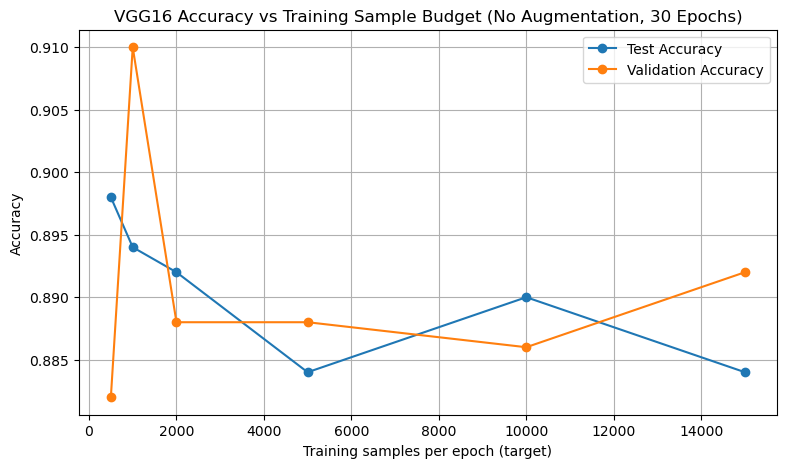

Best Q3 run: 500 samples/epoch (test_acc=0.8980)


In [6]:
sample_sizes = [500, 1000, 2000, 5000, 10000, 15000]
q3_results = []

no_aug = {'rescale': 1.0 / 255}

for n_samples in sample_sizes:
    # Approximate sample budget per epoch by controlling steps_per_epoch.
    steps = max(1, int(np.ceil(n_samples / BATCH_SIZE)))
    run_name = f'Q3_VGG16_noaug_{n_samples}samples'

    print(f'\nTraining {run_name} | steps_per_epoch={steps}, epochs=30')
    run = train_eval_save(
        model_name=run_name,
        backbone_name='VGG16',
        train_aug_kwargs=no_aug,
        epochs=30,
        early_stopping=False,  # fixed 30 epochs per requirement
        steps_per_epoch=steps,
    )

    q3_results.append({
        'samples_per_epoch_target': n_samples,
        'steps_per_epoch': steps,
        'epochs_ran': run['epochs_ran'],
        'final_train_acc': run['final_train_acc'],
        'final_val_acc': run['final_val_acc'],
        'final_test_acc': run['final_test_acc'],
        'train_time_sec': run['train_time_sec'],
        'model_h5_path': run['model_h5_path'],
    })

q3_df = pd.DataFrame(q3_results)
print('Q3 Results Table')
display(q3_df)

plt.figure(figsize=(9, 5))
plt.plot(q3_df['samples_per_epoch_target'], q3_df['final_test_acc'], marker='o', label='Test Accuracy')
plt.plot(q3_df['samples_per_epoch_target'], q3_df['final_val_acc'], marker='o', label='Validation Accuracy')
plt.xlabel('Training samples per epoch (target)')
plt.ylabel('Accuracy')
plt.title('VGG16 Accuracy vs Training Sample Budget (No Augmentation, 30 Epochs)')
plt.grid(True)
plt.legend()
plt.show()

best_q3 = q3_df.sort_values('final_test_acc', ascending=False).iloc[0]
print(
    f"Best Q3 run: {int(best_q3['samples_per_epoch_target'])} samples/epoch "
    f"(test_acc={best_q3['final_test_acc']:.4f})"
)

## 4) Implement Xception and Compare Architecture + Accuracy

Uses the same train/validation/test split configured at the start of this notebook.

In [7]:
q4_xception = train_eval_save(
    model_name='Q4_Xception',
    backbone_name='Xception',
    train_aug_kwargs=best_aug,
    epochs=30,
    early_stopping=True,
)

# Build unified comparison table using best model per type.
q1_best_row = q1_df.sort_values('final_test_acc', ascending=False).iloc[0]
q2_best_row = q2_df.sort_values('final_test_acc', ascending=False).iloc[0]

# Architecture metadata
arch_meta = {
    'VGG16': {
        'num_layers': len(VGG16(weights='imagenet', include_top=False, input_shape=(150, 150, 3)).layers),
        'num_params': VGG16(weights='imagenet', include_top=False, input_shape=(150, 150, 3)).count_params(),
    },
    'VGG19': {
        'num_layers': len(VGG19(weights='imagenet', include_top=False, input_shape=(150, 150, 3)).layers),
        'num_params': VGG19(weights='imagenet', include_top=False, input_shape=(150, 150, 3)).count_params(),
    },
    'Xception': {
        'num_layers': len(Xception(weights='imagenet', include_top=False, input_shape=(150, 150, 3)).layers),
        'num_params': Xception(weights='imagenet', include_top=False, input_shape=(150, 150, 3)).count_params(),
    },
}

q4_compare = pd.DataFrame([
    {
        'model_type': 'Best VGG16/VGG19 from Q2',
        'backbone': q2_best_row['backbone'],
        'num_layers': arch_meta[q2_best_row['backbone']]['num_layers'],
        'num_params': arch_meta[q2_best_row['backbone']]['num_params'],
        'final_val_acc': q2_best_row['final_val_acc'],
        'final_test_acc': q2_best_row['final_test_acc'],
        'model_h5_path': q2_best_row['model_h5_path'],
    },
    {
        'model_type': 'Best augmentation VGG16 from Q1',
        'backbone': 'VGG16',
        'num_layers': arch_meta['VGG16']['num_layers'],
        'num_params': arch_meta['VGG16']['num_params'],
        'final_val_acc': q1_best_row['final_val_acc'],
        'final_test_acc': q1_best_row['final_test_acc'],
        'model_h5_path': q1_best_row['model_h5_path'],
    },
    {
        'model_type': 'Xception (Q4)',
        'backbone': 'Xception',
        'num_layers': arch_meta['Xception']['num_layers'],
        'num_params': arch_meta['Xception']['num_params'],
        'final_val_acc': q4_xception['final_val_acc'],
        'final_test_acc': q4_xception['final_test_acc'],
        'model_h5_path': q4_xception['model_h5_path'],
    },
])

print('Q4 Comparison Table')
display(q4_compare.sort_values('final_test_acc', ascending=False).reset_index(drop=True))

q4_best = q4_compare.sort_values('final_test_acc', ascending=False).iloc[0]
print(
    f"Best overall in Q4 comparison: {q4_best['backbone']} "
    f"(test_acc={q4_best['final_test_acc']:.4f})"
)

Found 2000 images belonging to 2 classes.
Found 500 images belonging to 2 classes.
Found 500 images belonging to 2 classes.
Epoch 1/30


I0000 00:00:1777518795.806049   23842 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_181170__.123
E0000 00:00:1777518798.086268   23842 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1777518800.221768   23842 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1777518804.922548   23842 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1777518806.268170   23842 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


100/100 ━━━━━━━━━━━━━━━━━━━━ 44s 176ms/step - accuracy: 0.8025 - loss: 0.4424 - val_accuracy: 0.9500 - val_loss: 0.2286
Epoch 2/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 13s 127ms/step - accuracy: 0.9115 - loss: 0.2431 - val_accuracy: 0.9600 - val_loss: 0.1527
Epoch 3/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 115ms/step - accuracy: 0.9260 - loss: 0.1948 - val_accuracy: 0.9600 - val_loss: 0.1249
Epoch 4/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 13s 134ms/step - accuracy: 0.9310 - loss: 0.1666 - val_accuracy: 0.9660 - val_loss: 0.1122
Epoch 5/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 115ms/step - accuracy: 0.9450 - loss: 0.1509 - val_accuracy: 0.9660 - val_loss: 0.1059
Epoch 6/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 13s 125ms/step - accuracy: 0.9375 - loss: 0.1489 - val_accuracy: 0.9640 - val_loss: 0.1015
Epoch 7/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 20s 122ms/step - accuracy: 0.9360 - loss: 0.1374 - val_accuracy: 0.9620 - val_loss: 0.0971
Epoch 8/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 13s 128ms/step - accuracy: 0.9425 - loss: 0.1358 - val

Q4 Comparison Table


,model_type,backbone,num_layers,num_params,final_val_acc,final_test_acc,model_h5_path
0,Xception (Q4),Xception,132,20861480,0.962,0.964,/home/solyvie/workspace/cs-projects/25263CSDMa...
1,Best VGG16/VGG19 from Q2,VGG19,22,20024384,0.872,0.910,/home/solyvie/workspace/cs-projects/25263CSDMa...
2,Best augmentation VGG16 from Q1,VGG16,19,14714688,0.898,0.900,/home/solyvie/workspace/cs-projects/25263CSDMa...


Best overall in Q4 comparison: Xception (test_acc=0.9640)


## Example Classification on Unseen/Test Data

E0000 00:00:1777519230.840526   23842 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1777519235.062723   23842 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1777519238.765387   23842 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1777519242.503528   23842 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


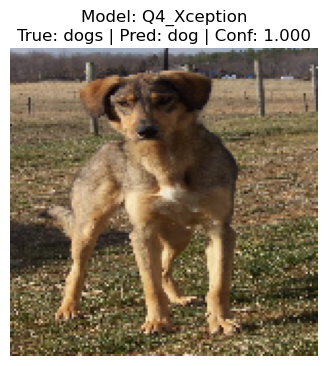

Example image path: /home/solyvie/workspace/cs-projects/25263CSDMachineLearning/[7] Group 8 - Module 6 CNN Part 3 - Using Pre-Trained Networks/data/working_split_for_lab3/test/dogs/8191.jpg
Best model used: Q4_Xception
Pred score (dog probability): 0.9998792409896851


In [8]:
# Pick best available model by test accuracy from Q2/Q4 and run one example prediction.
candidate_runs = [
    ('Q2_VGG16', q2_vgg16),
    ('Q2_VGG19', q2_vgg19),
    ('Q4_Xception', q4_xception),
]
best_name, best_run = sorted(candidate_runs, key=lambda x: x[1]['final_test_acc'], reverse=True)[0]
best_model = best_run['model_obj']

# Get one random image from test split.
all_test_images = []
for cls in ['cats', 'dogs']:
    cls_dir = test_dir / cls
    all_test_images.extend([(p, cls) for p in cls_dir.iterdir() if p.is_file()])

img_path, true_label = random.choice(all_test_images)
img = keras_image.load_img(str(img_path), target_size=IMG_SIZE)
img_arr = keras_image.img_to_array(img) / 255.0
img_arr = np.expand_dims(img_arr, axis=0)

pred_score = float(best_model.predict(img_arr, verbose=0)[0][0])
pred_label = 'dog' if pred_score >= 0.5 else 'cat'
confidence = pred_score if pred_label == 'dog' else (1 - pred_score)

plt.figure(figsize=(4, 4))
plt.imshow(img)
plt.title(
    f'Model: {best_name}\nTrue: {true_label} | Pred: {pred_label} | Conf: {confidence:.3f}'
)
plt.axis('off')
plt.show()

print('Example image path:', img_path)
print('Best model used:', best_name)
print('Pred score (dog probability):', pred_score)

## Final Insights (Auto-generated from your run)

In [9]:
# Summaries and exports for reporting.
summary = {
    'q1': q1_df.drop(columns=['history', 'model_obj'], errors='ignore').to_dict(orient='records'),
    'q2': q2_df.drop(columns=['history', 'model_obj'], errors='ignore').to_dict(orient='records'),
    'q3': q3_df.to_dict(orient='records'),
    'q4': {
        'xception': {k: v for k, v in q4_xception.items() if k not in ['history', 'model_obj']},
        'comparison_table': q4_compare.to_dict(orient='records'),
    },
    'dataset_split_note': split_note,
}

summary_json = OUTPUT_DIR / 'Group8_ANN_Lab3_summary.json'
with open(summary_json, 'w', encoding='utf-8') as f:
    import json
    json.dump(summary, f, indent=2)

q1_csv = OUTPUT_DIR / 'Group8_ANN_Lab3_q1_table.csv'
q2_csv = OUTPUT_DIR / 'Group8_ANN_Lab3_q2_table.csv'
q3_csv = OUTPUT_DIR / 'Group8_ANN_Lab3_q3_table.csv'
q4_csv = OUTPUT_DIR / 'Group8_ANN_Lab3_q4_table.csv'

q1_df.drop(columns=['history', 'model_obj'], errors='ignore').to_csv(q1_csv, index=False)
q2_df.drop(columns=['history', 'model_obj'], errors='ignore').to_csv(q2_csv, index=False)
q3_df.to_csv(q3_csv, index=False)
q4_compare.to_csv(q4_csv, index=False)

print('Saved summary JSON:', summary_json)
print('Saved tables:')
print(' -', q1_csv)
print(' -', q2_csv)
print(' -', q3_csv)
print(' -', q4_csv)

# Textual insights driven by metrics from this exact run.
q1_best = q1_df.sort_values('final_test_acc', ascending=False).iloc[0]
q2_best = q2_df.sort_values('final_test_acc', ascending=False).iloc[0]
q3_best = q3_df.sort_values('final_test_acc', ascending=False).iloc[0]
q4_best = q4_compare.sort_values('final_test_acc', ascending=False).iloc[0]

print('\n=== INSIGHTS ===')
print(f"Q1 Best Augmentation: {q1_best['model_name']} (test_acc={q1_best['final_test_acc']:.4f})")
print(f"Q2 Best Backbone:     {q2_best['backbone']} (test_acc={q2_best['final_test_acc']:.4f})")
print(
    f"Q3 Best Sample Budget: {int(q3_best['samples_per_epoch_target'])} samples/epoch "
    f"(test_acc={q3_best['final_test_acc']:.4f})"
)
print(f"Q4 Best Overall:      {q4_best['backbone']} (test_acc={q4_best['final_test_acc']:.4f})")

# Diminishing-return diagnostic for Q3
q3_sorted = q3_df.sort_values('samples_per_epoch_target').reset_index(drop=True)
q3_sorted['delta_test_acc'] = q3_sorted['final_test_acc'].diff()
print('\nQ3 marginal gains (test accuracy delta):')
display(q3_sorted[['samples_per_epoch_target', 'final_test_acc', 'delta_test_acc']])

Saved summary JSON: /home/solyvie/workspace/cs-projects/25263CSDMachineLearning/[7] Group 8 - Module 6 CNN Part 3 - Using Pre-Trained Networks/models/Group8_ANN_Lab3_summary.json
Saved tables:
 - /home/solyvie/workspace/cs-projects/25263CSDMachineLearning/[7] Group 8 - Module 6 CNN Part 3 - Using Pre-Trained Networks/models/Group8_ANN_Lab3_q1_table.csv
 - /home/solyvie/workspace/cs-projects/25263CSDMachineLearning/[7] Group 8 - Module 6 CNN Part 3 - Using Pre-Trained Networks/models/Group8_ANN_Lab3_q2_table.csv
 - /home/solyvie/workspace/cs-projects/25263CSDMachineLearning/[7] Group 8 - Module 6 CNN Part 3 - Using Pre-Trained Networks/models/Group8_ANN_Lab3_q3_table.csv
 - /home/solyvie/workspace/cs-projects/25263CSDMachineLearning/[7] Group 8 - Module 6 CNN Part 3 - Using Pre-Trained Networks/models/Group8_ANN_Lab3_q4_table.csv

=== INSIGHTS ===
Q1 Best Augmentation: Q1_VGG16_default_aug (test_acc=0.9000)
Q2 Best Backbone:     VGG19 (test_acc=0.9100)
Q3 Best Sample Budget: 500 samples

,samples_per_epoch_target,final_test_acc,delta_test_acc
0,500,0.898,NaN
1,1000,0.894,-0.004
2,2000,0.892,-0.002
3,5000,0.884,-0.008
4,10000,0.890,0.006
5,15000,0.884,-0.006


## Export to PDF

After running all cells, export the notebook as PDF:

```bash
jupyter nbconvert --to pdf Group8_ANN_Lab3.ipynb
```